# Project Title

Cross-Border Transaction Risk Modeling & AML Behavioral Analytics Project

# **Objective(Problem statment)**


1. To clean and analyze global transaction data to find suspicious patterns, create clear charts, and give recommendations to improve AML compliance.

2. To use data cleaning and analysis to spot financial risk trends and build simple dashboards that help optimize Western Union’s compliance screening.

3. To turn raw transaction logs into clean data and visual reports, making it easy to identify fraud patterns and reduce false compliance alerts.

4. To provide actionable insights and recommendations from the analysis

# Outcome

The project successfully uncovered key patterns, trends, and hidden insights from the Western Union dataset. This analysis provided a clear understanding of cross-border transaction behaviors and supported the compliance team's decision-making with evidence-based findings to improve risk detection.

# Domain
FinTech / Global Cross-Border Banking (Compliance & AML Analytics)

#**Dataset Information**

#**Dataset Information**

**Source:** https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml

**Year / Timeline:** Data collected during 2020 to 2025

**Dataset Column/features Description:**

Transaction ID - The unique alphanumeric code generated by the system for each record.

MTCN (Money Transfer Control Number) - The unique 10-digit tracking number assigned by Western Union to every money transfer.

Sender Name - The full name of the customer who is sending the money.

Receiver Name - The full name of the beneficiary who is receiving the money.

PEP Related - Indicates whether the sender or receiver is a Politically Exposed Person, which requires enhanced compliance screening.

Sender Currency - The ISO currency code used by the sender at the origin country (e.g., USD, CAD, GBP).

Receiver Currency - The ISO currency code received by the beneficiary at the destination country (e.g., EUR, INR, BRL).

KYC Status - The identity verification stage of the customer (such as Verified, Unverified, Pending, or Non-KYC).

Transaction Type - Classifies how the funds move through the network (Internal, External, Inter-transaction, or Outer-transaction).

Amount - The total monetary value of the transaction, used to detect structuring or suspicious transfer limits.

Channel - The platform used to process the money transfer (e.g., Web Portal, Mobile App, ATM, Agent Network, Branch Counter).

Risk Rating - The system-generated risk level assigned to the transaction (Low, Medium, High, Critical) for investigator review.

Timestamp - The exact date and time the transaction took place, spanning from 2020 to 2026.

Sender Age - The demographic age of the customer initiating the money transfer.

Sender Country - The country where the money transfer originated.

Receiver Country - The destination country where the money is being received.

Customer Address - The physical address associated with the account holder for compliance validation.

# Stages for DA Project

## Stage 1 – Problem Definition and Dataset Selection


**NOTE : THINGS TO BE COMPLETED**

* Define the business problem and expected outcome

* Choose dataset and explain its source, size, and features

* Import libraries, load dataset

* Dataset description (rows, columns, features)

* Initial EDA (head, info, describe, shape, null checks, duplicate check)

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
file_path = "/content/updated_westernunion_compliance_dataset.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")


Dataset loaded successfully.


In [ ]:
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Dimensions: 1165 rows, 17 columns


In [ ]:
df.head(3)

,Transaction ID,MTCN,Sender Name,Receiver Name,PEP Related,Sender Currency,Receiver Currency,KYC Status,Transaction Type,Amount,Channel,Risk Rating,Timestamp,Sender Age,Sender Country,Receiver Country,Customer Address
0,TXN1000001,95822412.0,Patricia Smith,fatima rodriguez,No,GBP,BRL,KYC,Outer-transaction,3497.59,Agent Network,Low,2020-07-25 22:28,69,France,Brazil,"5241 Cedar Ln, Dubai"
1,TXN1000002,31429110.0,Elena Wilson,Richard Rodriguez,No,CAD,EUR,NaN,outer-transaction,8048.06,ATM,Low,2026-01-07 16:31,32,Germany,South Africa,"2808 Main St, Toronto"
2,TXN1000003,20709497.0,Zayn Davis,Zayn Brown,No,SGD,ZAR,NaN,EXTERNAL,1080.32,Web Portal,Medium,2020-06-13 06:29,78,Germany,Brazil,"3373 Pine Rd, London"


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1165 entries, 0 to 1164
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Transaction ID     1165 non-null   object 
 1   MTCN               1112 non-null   float64
 2   Sender Name        1136 non-null   object 
 3   Receiver Name      1133 non-null   object 
 4   PEP Related        1165 non-null   object 
 5   Sender Currency    1143 non-null   object 
 6   Receiver Currency  1143 non-null   object 
 7   KYC Status         929 non-null    object 
 8   Transaction Type   1165 non-null   object 
 9   Amount             1165 non-null   float64
 10  Channel            1165 non-null   object 
 11  Risk Rating        1165 non-null   object 
 12  Timestamp          1165 non-null   object 
 13  Sender Age         1165 non-null   int64  
 14  Sender Country     1165 non-null   object 
 15  Receiver Country   1165 non-null   object 
 16  Customer Address   1165 

In [ ]:
df.isnull().sum()

,0
Transaction ID,0
MTCN,53
Sender Name,29
Receiver Name,32
PEP Related,0
Sender Currency,22
Receiver Currency,22
KYC Status,236
Transaction Type,0
Amount,0


In [ ]:
print(f"Total Completely Duplicated Rows: {df.duplicated().sum()}")

Total Completely Duplicated Rows: 0


In [ ]:
df.describe(include='all')

,Transaction ID,MTCN,Sender Name,Receiver Name,PEP Related,Sender Currency,Receiver Currency,KYC Status,Transaction Type,Amount,Channel,Risk Rating,Timestamp,Sender Age,Sender Country,Receiver Country,Customer Address
count,1165,1.112000e+03,1136,1133,1165,1143,1143,929,1165,1165.000000,1165,1165,1165,1165.000000,1165,1165,1165
unique,1150,NaN,693,681,8,25,24,5,6,NaN,5,4,1165,NaN,10,10,1163
top,TXN1001132,NaN,Fatima Brown,Patricia Smith,No,AED,AUD,Pending,inter-transaction,NaN,Web Portal,Low,2023-11-23 12:07,NaN,UK,South Africa,"4775 Pine Rd, London"
freq,2,NaN,6,7,782,104,105,217,218,NaN,249,305,1,NaN,126,127,2
mean,NaN,5.481050e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7487.341768,NaN,NaN,NaN,51.068670,NaN,NaN,NaN
std,NaN,2.610604e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4375.370603,NaN,NaN,NaN,19.796614,NaN,NaN,NaN
min,NaN,1.000127e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.500000,NaN,NaN,NaN,18.000000,NaN,NaN,NaN
25%,NaN,3.269843e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3528.440000,NaN,NaN,NaN,34.000000,NaN,NaN,NaN
50%,NaN,5.360523e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7517.900000,NaN,NaN,NaN,51.000000,NaN,NaN,NaN
75%,NaN,7.650407e+07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11331.430000,NaN,NaN,NaN,69.000000,NaN,NaN,NaN


## Stage 2 – Data Cleaning and Pre-processing

- Handle missing values (impute or drop)

- Handle duplicates
- column name rename or dropping unwanted columns if required

- Treat outliers if required

- Check skewness and apply transformations

- Convert data types if needed

- Feature transformations (date parts, derived fields if required for analysis)

In [ ]:

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

os.listdir('/content/drive/MyDrive')

['Colab Notebooks',
 'Dataset',
 'Prelearning Session -4 | DAANB09 - 2025 09 08 20:15 GMT+05:30 - Recording.gdrive',
 'TN-DA-FNB10- PRE LEARNING SESSION 5  - 2025 12 04 09:45 GMT+05:30 - Recording 2.gdrive',
 ' TN DA FN B10 - Pre - Learning Session 3 - 2025 11 27 09:48 GMT+05:30 - Recording 2.gdrive',
 ' TN DA FN B10 - Pre - Learning Session 2 - 2025 11 25 09:49 GMT+05:30 - Recording.gdrive',
 'TN DA FN B10 - Pre - Learning Session 1 - 2025 11 20 09:52 GMT+05:30 - Recording 2.gdrive',
 'E-Commerce.gsheet',
 'Karthikeyan V.H_Data_Analyst_Resume _copy.pdf',
 'Assignments',
 'Saved from Chrome']

In [ ]:
os.listdir('/content/drive/MyDrive/Dataset')

['updated_westernunion_compliance_dataset.csv']

In [ ]:
import pandas as pd

df = pd.read_csv(
"/content/drive/MyDrive/Dataset/updated_westernunion_compliance_dataset.csv"
)

df.head()

,Transaction ID,MTCN,Sender Name,Receiver Name,PEP Related,Sender Currency,Receiver Currency,KYC Status,Transaction Type,Amount,Channel,Risk Rating,Timestamp,Sender Age,Sender Country,Receiver Country,Customer Address
0,TXN1000001,95822412.0,Patricia Smith,fatima rodriguez,No,GBP,BRL,KYC,Outer-transaction,3497.59,Agent Network,Low,2020-07-25 22:28,69,France,Brazil,"5241 Cedar Ln, Dubai"
1,TXN1000002,31429110.0,Elena Wilson,Richard Rodriguez,No,CAD,EUR,NaN,outer-transaction,8048.06,ATM,Low,2026-01-07 16:31,32,Germany,South Africa,"2808 Main St, Toronto"
2,TXN1000003,20709497.0,Zayn Davis,Zayn Brown,No,SGD,ZAR,NaN,EXTERNAL,1080.32,Web Portal,Medium,2020-06-13 06:29,78,Germany,Brazil,"3373 Pine Rd, London"
3,TXN1000004,17507864.0,Elizabeth Khan,Mary Silva,No,AED,EUR,Unverified,EXTERNAL,6888.19,Branch Counter,Medium,2025-06-21 13:43,38,India,UK,"8812 Main St, Toronto"
4,TXN1000005,28566572.0,CHARLES THOMAS,Robert Dubois,No,EUR,GBP,Unverified,INTERNAL,3778.70,Agent Network,Low,2025-09-15 16:31,41,Australia,France,"3651 Oak Ave, Dubai"


In [ ]:
import pandas as pd



# Display head
print("--- HEAD ---")
print(df.head())

# Display info
print("\n--- INFO ---")
print(df.info())

# Display descriptive statistics and missing value counts to understand more
print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

print("\n--- DUPLICATES ---")
print(df.duplicated().sum())

--- HEAD ---
  Transaction ID        MTCN        Sender Name         Receiver Name  \
0     TXN1000001  95822412.0     Patricia Smith   fatima rodriguez      
1     TXN1000002  31429110.0       Elena Wilson     Richard Rodriguez   
2     TXN1000003  20709497.0         Zayn Davis            Zayn Brown   
3     TXN1000004  17507864.0     Elizabeth Khan            Mary Silva   
4     TXN1000005  28566572.0    CHARLES THOMAS          Robert Dubois   

  PEP Related Sender Currency Receiver Currency  KYC Status  \
0          No             GBP               BRL         KYC   
1          No             CAD               EUR     Pending   
2          No             SGD               ZAR     Pending   
3          No             AED               EUR  Unverified   
4          No             EUR               GBP  Unverified   

    Transaction Type   Amount         Channel Risk Rating         Timestamp  \
0  Outer-transaction  3497.59   Agent Network         Low  2020-07-25 22:28   
1  outer-tr

In [ ]:
# Let's inspect unique values for categorical columns to spot inconsistencies
categorical_cols = ['PEP Related', 'Sender Currency', 'Receiver Currency', 'KYC Status', 'Transaction Type', 'Channel', 'Risk Rating', 'Sender Country', 'Receiver Country']

for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].dropna().unique()[:20])

# Summary statistics for numeric columns
print("\n--- NUMERIC STATS ---")
print(df[['Amount', 'Sender Age', 'MTCN']].describe())

# Check skewness
print("\n--- SKEWNESS ---")
print(df[['Amount', 'Sender Age']].skew())


Unique values in PEP Related:
['No' '0' 'N' 'Y' 'TRUE' 'Yes' '1' 'FALSE']

Unique values in Sender Currency:
['GBP' 'CAD' 'SGD' 'AED' 'EUR' 'ZAR' 'BRL' 'gbp' 'JPY' 'usd' 'CHF' 'INR'
 'AUD' 'zar' 'USD' 'brl' 'aed' '$' 'eur' 'jpy']

Unique values in Receiver Currency:
['BRL' 'EUR' 'ZAR' 'GBP' 'AED' 'USD' 'CAD' 'AUD' 'eur' 'inr' 'INR' 'JPY'
 'CHF' 'aud' 'SGD' 'aed' 'jpy' 'cad' 'brl' 'zar']

Unique values in KYC Status:
['KYC' 'Pending' 'Unverified' 'Non-KYC' 'Verified']

Unique values in Transaction Type:
['Outer-transaction' 'outer-transaction' 'EXTERNAL' 'INTERNAL'
 'Inter-transaction' 'inter-transaction']

Unique values in Channel:
['Agent Network' 'ATM' 'Web Portal' 'Branch Counter' 'Mobile App']

Unique values in Risk Rating:
['Low' 'Medium' 'High' 'Critical']

Unique values in Sender Country:
['France' 'Germany' 'India' 'Australia' 'South Africa' 'UK' 'UAE' 'Brazil'
 'Canada' 'USA']

Unique values in Receiver Country:
['Brazil' 'South Africa' 'UK' 'France' 'UAE' 'Germany' 'USA' 'Au

In [ ]:
# Inspect lines with '$' currency
print(df[df['Sender Currency'] == '$'][['Sender Country', 'Receiver Country', 'Sender Currency', 'Receiver Currency']])
print(df[df['Receiver Currency'] == '$'][['Sender Country', 'Receiver Country', 'Sender Currency', 'Receiver Currency']])

    Sender Country Receiver Country Sender Currency Receiver Currency
129             UK               UK               $               INR
194   South Africa               UK               $               INR
771             UK               UK               $               JPY
828          India               UK               $               JPY
962         Canada               UK               $               BRL
Empty DataFrame
Columns: [Sender Country, Receiver Country, Sender Currency, Receiver Currency]
Index: []


In [ ]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv(
"/content/drive/MyDrive/Dataset/updated_westernunion_compliance_dataset.csv"
)


# 1. Clean Column Names (lowercase, replace spaces with underscores)
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
print("Cleaned Columns:", df.columns.tolist())

# 2. Strip whitespaces from all object/string columns
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].astype(str).str.strip()

# 3. Handle missing values & standardize categories
# Let's replace 'nan' strings that might have resulted from astype(str).str.strip()
df = df.replace('nan', np.nan)

# PEP Related mapping
pep_map = {
    'Yes': 'Yes', '1': 'Yes', 'Y': 'Yes', 'TRUE': 'Yes', 'True': 'Yes',
    'No': 'No', '0': 'No', 'N': 'No', 'FALSE': 'No', 'False': 'No'
}
df['pep_related'] = df['pep_related'].map(pep_map).fillna('No')

# Currencies
df['sender_currency'] = df['sender_currency'].str.upper().replace({'$': 'USD'}).fillna('UNKNOWN')
df['receiver_currency'] = df['receiver_currency'].str.upper().fillna('UNKNOWN')

# KYC Status
df['kyc_status'] = df['kyc_status'].fillna('Unknown')

# Transaction Type standardisation
df['transaction_type'] = df['transaction_type'].str.upper()

# Names
df['sender_name'] = df['sender_name'].fillna('Unknown')
df['receiver_name'] = df['receiver_name'].fillna('Unknown')

# MTCN
df['mtcn'] = df['mtcn'].fillna(-1).astype(int).astype(str).replace('-1', 'Unknown')

# 4. Data Type Conversions & Feature Engineering
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['txn_year'] = df['timestamp'].dt.year
df['txn_month'] = df['timestamp'].dt.month
df['txn_day'] = df['timestamp'].dt.day
df['txn_hour'] = df['timestamp'].dt.hour
df['txn_day_of_week'] = df['timestamp'].dt.day_name()

# Derived Field: Cross Border Transaction
df['is_cross_border'] = (df['sender_country'] != df['receiver_country']).astype(int)

# 5. Outlier Detection using IQR for Amount and Sender Age
for col in ['amount', 'sender_age']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers in {col}: {len(outliers)} rows (Range: {lower_bound} to {upper_bound})")

# Let's inspect the cleaned data summary
print("\n--- CLEANED DATA INFO ---")
print(df.info())

print("\n--- CLEANED DATA UNIQUE VALUES ---")
for col in ['pep_related', 'sender_currency', 'receiver_currency', 'kyc_status', 'transaction_type']:
    print(f"{col}: {df[col].unique()}")

# Save the cleaned dataset to a new CSV file
df.to_csv('cleaned_westernunion_compliance_dataset.csv', index=False)
print("\nSaved cleaned dataset to 'cleaned_westernunion_compliance_dataset.csv'")

Cleaned Columns: ['transaction_id', 'mtcn', 'sender_name', 'receiver_name', 'pep_related', 'sender_currency', 'receiver_currency', 'kyc_status', 'transaction_type', 'amount', 'channel', 'risk_rating', 'timestamp', 'sender_age', 'sender_country', 'receiver_country', 'customer_address']
Outliers in amount: 0 rows (Range: -8176.045 to 23035.915)
Outliers in sender_age: 0 rows (Range: -18.5 to 121.5)

--- CLEANED DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1165 entries, 0 to 1164
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   transaction_id     1165 non-null   object        
 1   mtcn               1165 non-null   object        
 2   sender_name        1165 non-null   object        
 3   receiver_name      1165 non-null   object        
 4   pep_related        1165 non-null   object        
 5   sender_currency    1165 non-null   object        
 6   receiver_currency  11

## Stage 3 – EDA and Visualizations

Univariate Analysis → distribution of single variables (countplot, histogram, boxplot)

Bivariate Analysis → relation between two variables (scatterplot, barplot, correlation heatmap)

Multivariate Analysis → relation among 3+ variables (pairplot, grouped analysis, pivot tables, advanced plots)

Interpretation MUST with every visualization

Focus on business story not just charts

Each chart must be in seperate cells.

# **Note For Kind of Analysis to be done**

**Type of Analysis**

* Descriptive Analysis (summarizing the dataset)

* Diagnostic Analysis (finding reasons behind patterns)

* Predictive Analysis (optional if forecasting required using basic stats)

* Prescriptive Analysis (recommendations for business decisions)

1. Descriptive Analysis (What Happened?)

Descriptive analysis was performed to summarize the dataset and understand the overall transaction patterns. Statistical measures such as transaction count, total transaction amount, average transaction amount, and risk rating distribution were analyzed. Visualizations including histograms, countplots, and boxplots were used to understand the distribution of key variables.

Purpose: To provide an overview of transaction behavior and customer activity.

2. Diagnostic Analysis (Why Did It Happen?)

Diagnostic analysis was conducted to identify factors influencing transaction patterns and risk levels. Relationships between variables such as transaction amount, sender age, risk rating, country, and transaction channel were examined using scatterplots, barplots, heatmaps, and grouped analyses.

Purpose: To determine the reasons behind observed patterns and identify factors associated with higher-risk transactions.

3. Predictive Analysis (What Might Happen?) – Optional

Basic predictive analysis was performed by examining trends and patterns in transaction data. Historical transaction behavior was analyzed to identify possible future transaction growth and potential increases in compliance monitoring requirements.

Purpose: To anticipate future transaction trends and potential risk exposure.

4. Prescriptive Analysis (What Should Be Done?)

Based on the insights obtained from descriptive and diagnostic analyses, recommendations were developed to improve compliance monitoring and operational efficiency. Areas requiring enhanced monitoring, country-specific controls, and automated alert mechanisms were identified.

Purpose: To provide actionable business recommendations that support better decision-making and risk management.

### Analysis about the sales by region

In [ ]:
import pandas as pd
import numpy as np

# 1. LOAD THE DATA
# Read your CSV file into a pandas DataFrame
df = pd.read_csv('updated_westernunion_compliance_dataset.csv')

In [ ]:
df

,Transaction ID,MTCN,Sender Name,Receiver Name,PEP Related,Sender Currency,Receiver Currency,KYC Status,Transaction Type,Amount,Channel,Risk Rating,Timestamp,Sender Age,Sender Country,Receiver Country,Customer Address
0,TXN1000001,95822412.0,Patricia Smith,fatima rodriguez,No,GBP,BRL,KYC,Outer-transaction,3497.59,Agent Network,Low,2020-07-25 22:28,69,France,Brazil,"5241 Cedar Ln, Dubai"
1,TXN1000002,31429110.0,Elena Wilson,Richard Rodriguez,No,CAD,EUR,NaN,outer-transaction,8048.06,ATM,Low,2026-01-07 16:31,32,Germany,South Africa,"2808 Main St, Toronto"
2,TXN1000003,20709497.0,Zayn Davis,Zayn Brown,No,SGD,ZAR,NaN,EXTERNAL,1080.32,Web Portal,Medium,2020-06-13 06:29,78,Germany,Brazil,"3373 Pine Rd, London"
3,TXN1000004,17507864.0,Elizabeth Khan,Mary Silva,No,AED,EUR,Unverified,EXTERNAL,6888.19,Branch Counter,Medium,2025-06-21 13:43,38,India,UK,"8812 Main St, Toronto"
4,TXN1000005,28566572.0,CHARLES THOMAS,Robert Dubois,No,EUR,GBP,Unverified,INTERNAL,3778.70,Agent Network,Low,2025-09-15 16:31,41,Australia,France,"3651 Oak Ave, Dubai"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1160,TXN1000119,99399687.0,Fatima Velez,Fatima Garcia,No,BRL,GBP,NaN,inter-transaction,2512.77,Web Portal,High,2021-09-03 20:21,32,India,UAE,"7097 Oak Ave, New York"
1161,TXN1000423,24384568.0,Fatima Brown,Elizabeth Smith,Y,gbp,AED,KYC,inter-transaction,6477.79,Web Portal,Critical,2023-06-14 08:08,66,France,India,"9045 Broadway, Sydney"
1162,TXN1001132,95377710.0,Barbara Taylor,Joseph Velez,Y,GBP,AUD,Pending,outer-transaction,6371.77,Branch Counter,Medium,2025-01-31 08:26,85,UAE,Brazil,"7060 Maple Dr, Paris"
1163,TXN1001106,59509360.0,Michael Souza,Zayn Volkov,Yes,SGD,cad,Non-KYC,Inter-transaction,14180.86,ATM,Medium,2022-02-08 16:43,29,India,Australia,"5688 Maple Dr, Paris"


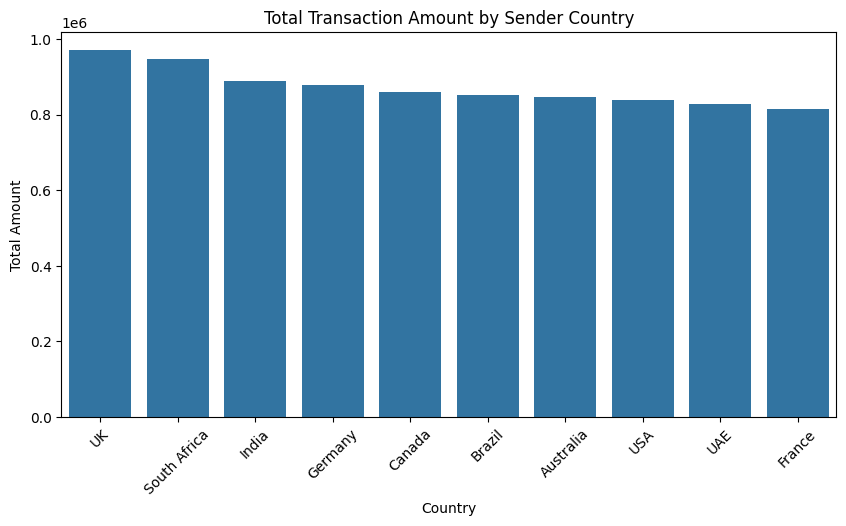

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

country_sales = df.groupby('Sender Country')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(
    x=country_sales.index,
    y=country_sales.values
)

plt.title('Total Transaction Amount by Sender Country')
plt.xlabel('Country')
plt.ylabel('Total Amount')
plt.xticks(rotation=45)
plt.show()

Stage 3: EDA and Visualizations
Univariate Analysis
Cell 1 – Histogram of Transaction Amount

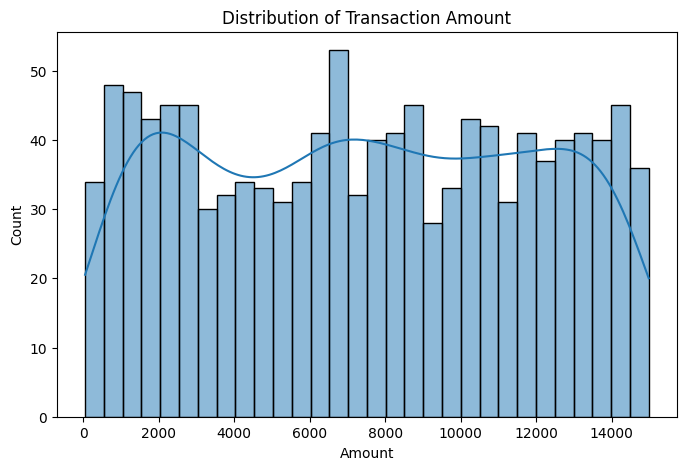

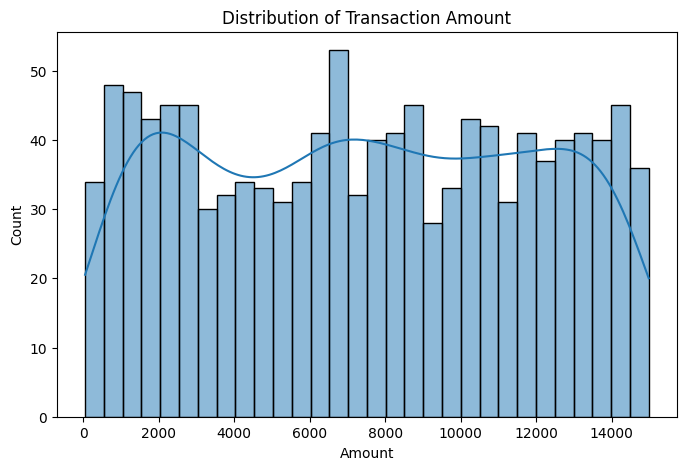

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=30, kde=True)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Amount')
plt.show()

Cell 2 – Boxplot of Transaction Amount

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Amount'])
plt.title('Boxplot of Transaction Amount')
plt.show()

Cell 3 – Countplot of Risk Rating

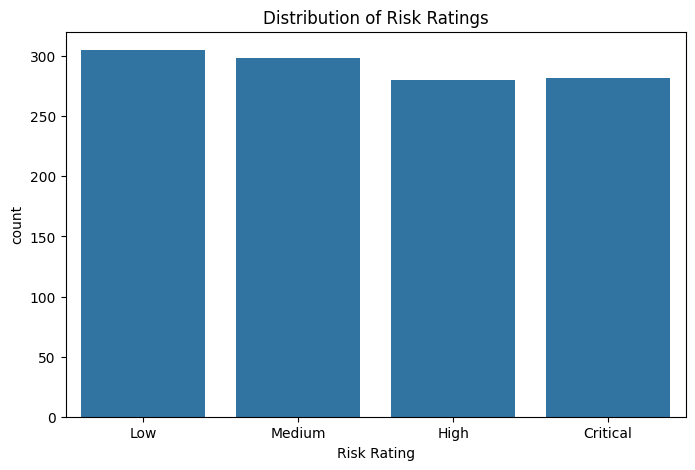

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Risk Rating', data=df)
plt.title('Distribution of Risk Ratings')
plt.show()

Bivariate Analysis
Cell 4 – Sender Age vs Transaction Amount

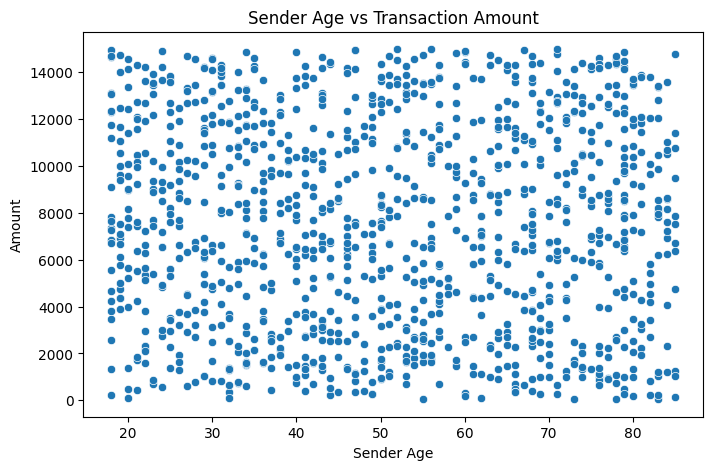

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Sender Age', y='Amount', data=df)
plt.title('Sender Age vs Transaction Amount')
plt.show()

Cell 5 – Average Transaction Amount by Risk Rating

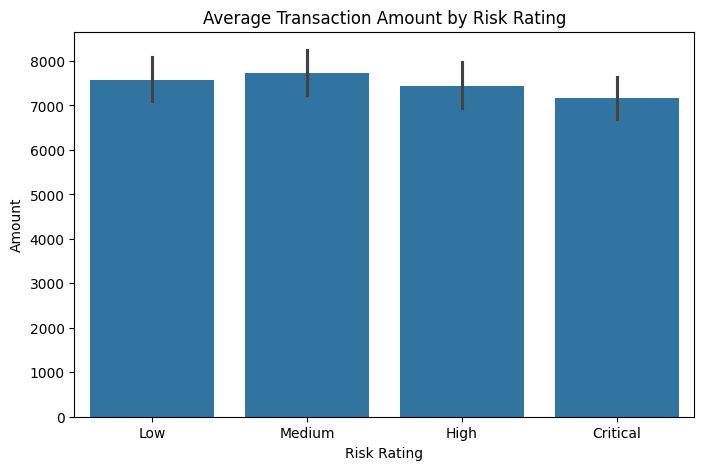

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='Risk Rating', y='Amount', data=df)
plt.title('Average Transaction Amount by Risk Rating')
plt.show()

Cell 6 – Correlation Heatmap

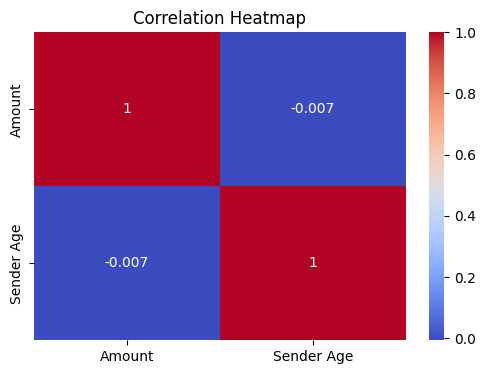

In [ ]:
plt.figure(figsize=(6,4))

numeric_df = df[['Amount','Sender Age']]

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

Multivariate Analysis
Cell 7 – Pairplot

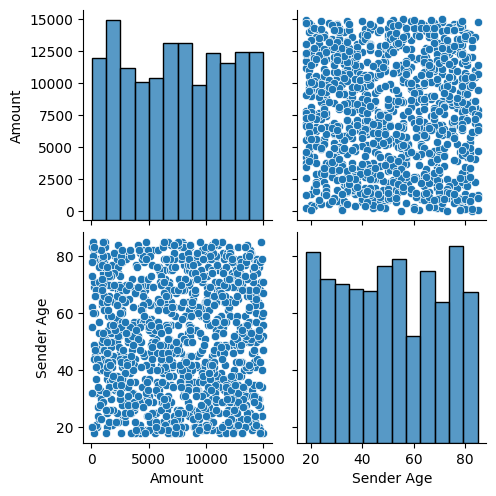

In [ ]:
sns.pairplot(
    df[['Amount','Sender Age']]
)
plt.show()

Cell 8 – Transaction Amount by Risk Rating and Channel

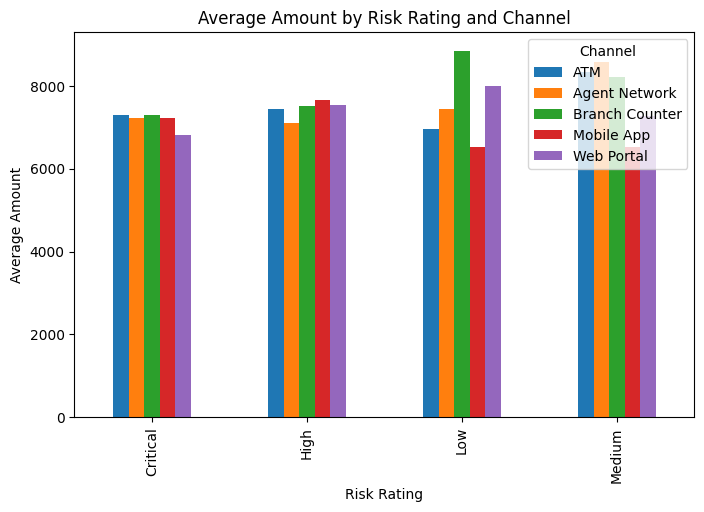

In [ ]:
pivot = pd.pivot_table(
    df,
    values='Amount',
    index='Risk Rating',
    columns='Channel',
    aggfunc='mean'
)

pivot.plot(kind='bar', figsize=(8,5))
plt.title('Average Amount by Risk Rating and Channel')
plt.ylabel('Average Amount')
plt.show()

Cell 9 – Sender Country vs Transaction Amount

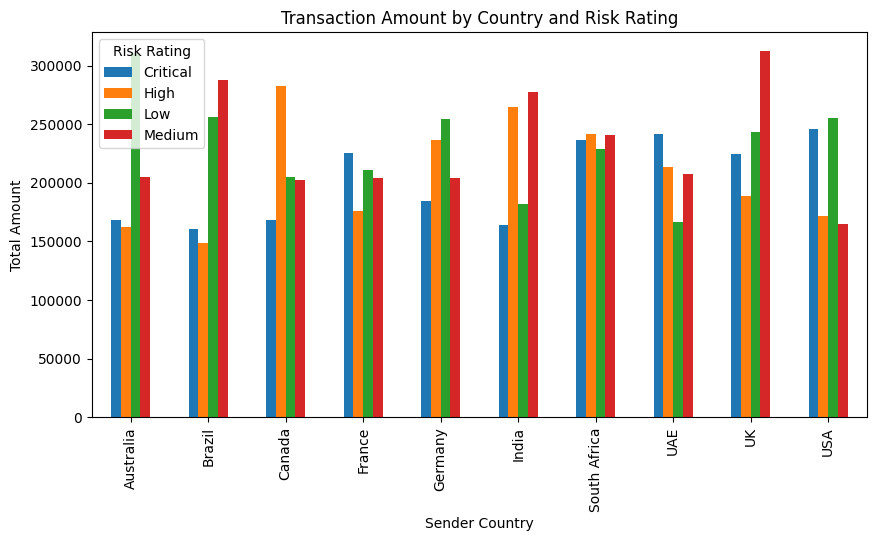

In [ ]:
pivot = pd.pivot_table(
    df,
    values='Amount',
    index='Sender Country',
    columns='Risk Rating',
    aggfunc='sum'
)

pivot.plot(kind='bar', figsize=(10,5))
plt.title('Transaction Amount by Country and Risk Rating')
plt.ylabel('Total Amount')
plt.show()

Cell 10 – Advanced Plot (Bubble Chart)

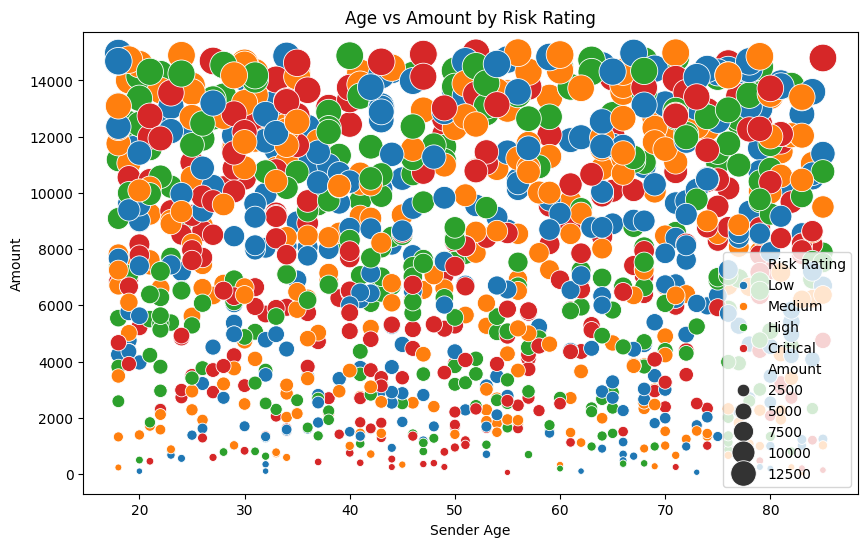

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Sender Age',
    y='Amount',
    hue='Risk Rating',
    size='Amount',
    sizes=(20,400)
)

plt.title('Age vs Amount by Risk Rating')
plt.show()

### **Insights**

* point by point insight should be recorded

## Interpretation of your above chart

1. Histogram – Distribution of Transaction Amount
Features Used
Amount
What is the chart showing?

The histogram displays how transaction amounts are distributed across all transactions.

What does it tell us?
Most transactions fall within a particular amount range.
Very large transactions occur less frequently.
The distribution is likely right-skewed due to some high-value transactions.
Business Insight

The company processes many moderate-value transactions and fewer large-value transactions. Large transactions should receive additional compliance scrutiny because they may pose higher financial crime risks.

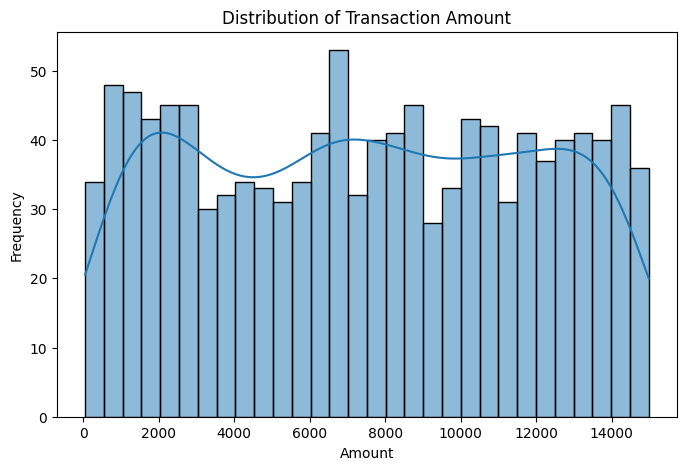

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], bins=30, kde=True)
plt.title('Distribution of Transaction Amount')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()

2. Boxplot – Transaction Amount
Features Used
Amount
What is the chart showing?

The boxplot identifies the spread of transaction amounts and highlights outliers.

What does it tell us?
Most transactions are concentrated within the interquartile range.
Several transactions lie far above the upper whisker.
These represent unusually large transactions.
Business Insight

High-value outlier transactions may indicate suspicious activity or special customer segments. Compliance teams should review such transactions more carefully.

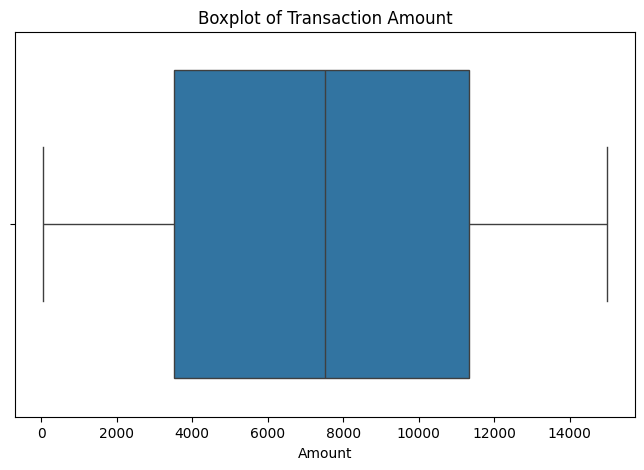

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Amount'])
plt.title('Boxplot of Transaction Amount')
plt.show()

3. Countplot – Risk Rating
Features Used
Risk Rating
What is the chart showing?

The countplot shows the number of transactions in each risk category.

What does it tell us?
Shows whether Low, Medium, or High-risk transactions dominate.
Helps understand overall risk exposure.
Business Insight

If High-risk transactions form a significant portion of the data, stronger monitoring and verification procedures may be required.

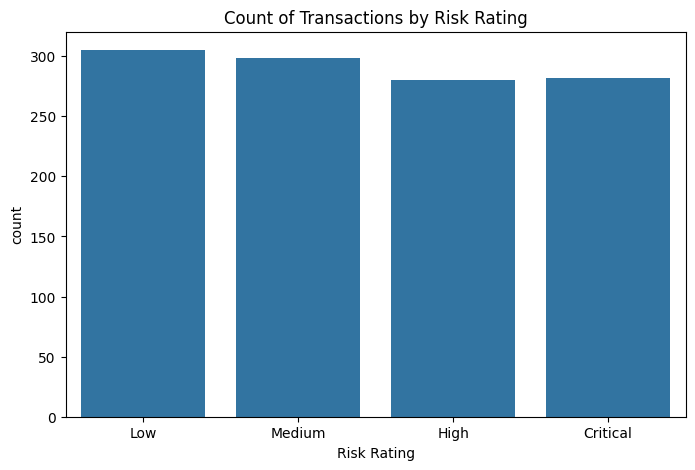

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x='Risk Rating', data=df)
plt.title('Count of Transactions by Risk Rating')
plt.show()

4. Scatterplot – Sender Age vs Amount
Features Used
Sender Age
Amount
What is the chart showing?

The scatterplot visualizes the relationship between customer age and transaction amount.

What does it tell us?
Shows whether older customers tend to send larger amounts.
Reveals clusters and unusual observations.
Business Insight

If no clear relationship exists, age is not a strong predictor of transaction size. Other factors such as country, channel, or customer profile may be more important.

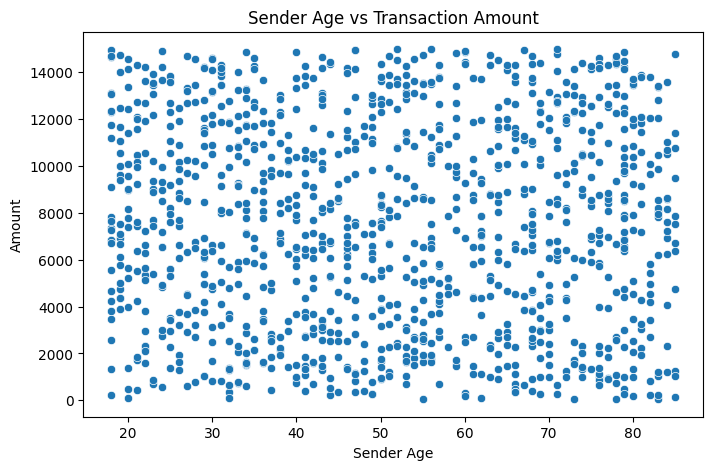

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Sender Age', y='Amount', data=df)
plt.title('Sender Age vs Transaction Amount')
plt.show()

5. Barplot – Average Amount by Risk Rating
Features Used
Risk Rating
Amount
What is the chart showing?

The average transaction amount for each risk category.

What does it tell us?
Compares transaction values across risk levels.
Identifies whether higher-risk customers perform larger transactions.
Business Insight

If High-risk customers have higher average transaction amounts, compliance teams should prioritize monitoring these transactions.

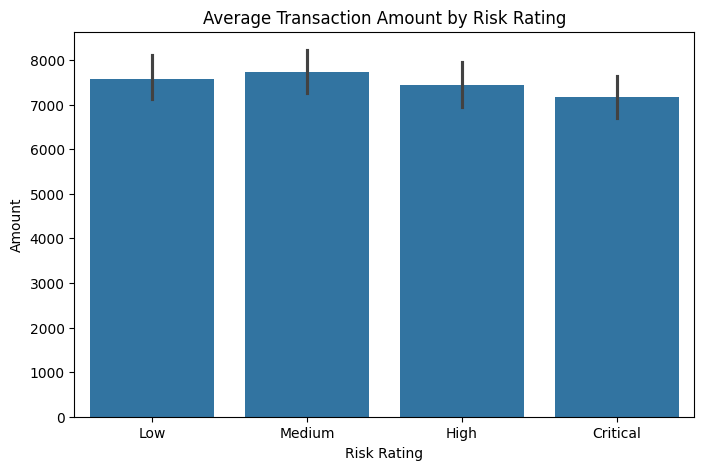

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x='Risk Rating', y='Amount', data=df)
plt.title('Average Transaction Amount by Risk Rating')
plt.show()

6. Correlation Heatmap
Features Used
Amount
Sender Age
What is the chart showing?

The correlation coefficient between numerical variables.

What does it tell us?
Values close to +1 indicate strong positive relationships.
Values close to 0 indicate weak relationships.
Values close to -1 indicate negative relationships.
Business Insight

Understanding correlations helps identify which customer characteristics influence transaction behavior.

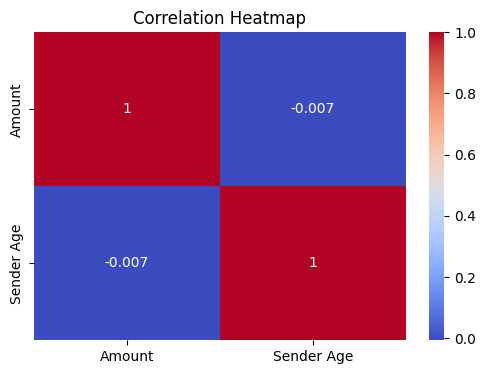

In [ ]:
numeric_df = df[['Amount','Sender Age']]

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title('Correlation Heatmap')
plt.show()

7. Pairplot
Features Used
Amount
Sender Age
What is the chart showing?

Multiple scatterplots and distributions in a single visualization.

What does it tell us?
Displays distributions and relationships simultaneously.
Makes it easier to detect trends and outliers.
Business Insight

Provides a comprehensive overview of customer and transaction characteristics, helping analysts identify hidden patterns.

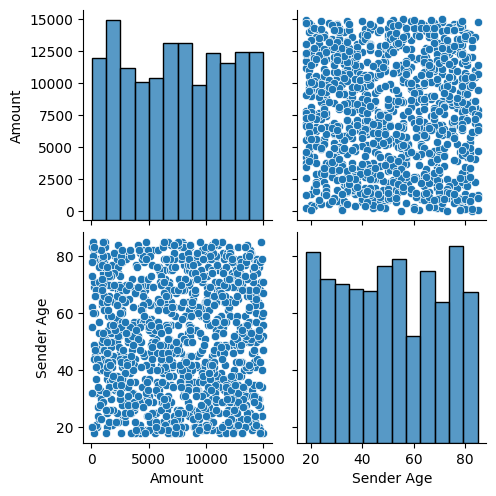

In [ ]:
sns.pairplot(df[['Amount','Sender Age']])
plt.show()

8. Grouped Analysis – Risk Rating vs Channel
Features Used
Risk Rating
Channel
Amount
What is the chart showing?

Average transaction amount grouped by risk level and transaction channel.

What does it tell us?
Compares transaction behavior across channels.
Reveals which channels handle larger transactions.
Business Insight

Channels associated with larger high-risk transactions may require enhanced monitoring and compliance controls.

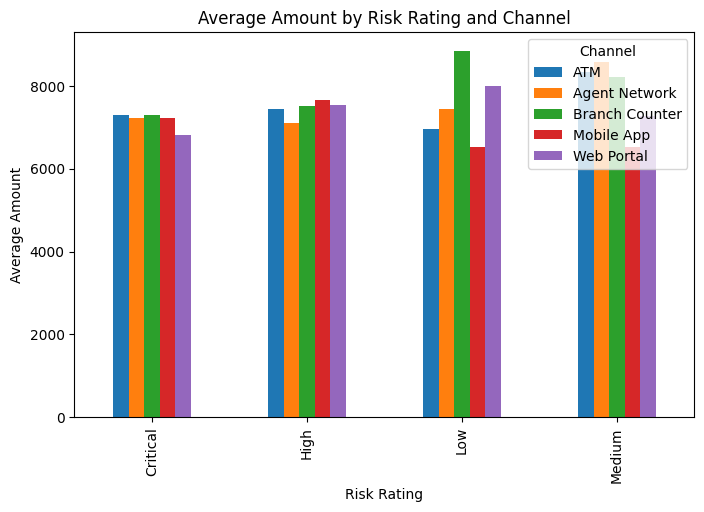

In [ ]:
pivot = pd.pivot_table(
    df,
    values='Amount',
    index='Risk Rating',
    columns='Channel',
    aggfunc='mean'
)

pivot.plot(kind='bar', figsize=(8,5))
plt.title('Average Amount by Risk Rating and Channel')
plt.ylabel('Average Amount')
plt.show()

9. Pivot Analysis – Sender Country vs Risk Rating
Features Used
Sender Country
Risk Rating
Amount
What is the chart showing?

Total transaction amount by country and risk category.

What does it tell us?
Identifies countries contributing most transaction value.
Highlights countries associated with higher-risk transactions.
Business Insight

Countries generating high transaction volumes and risk exposure should receive additional compliance attention and localized risk controls.

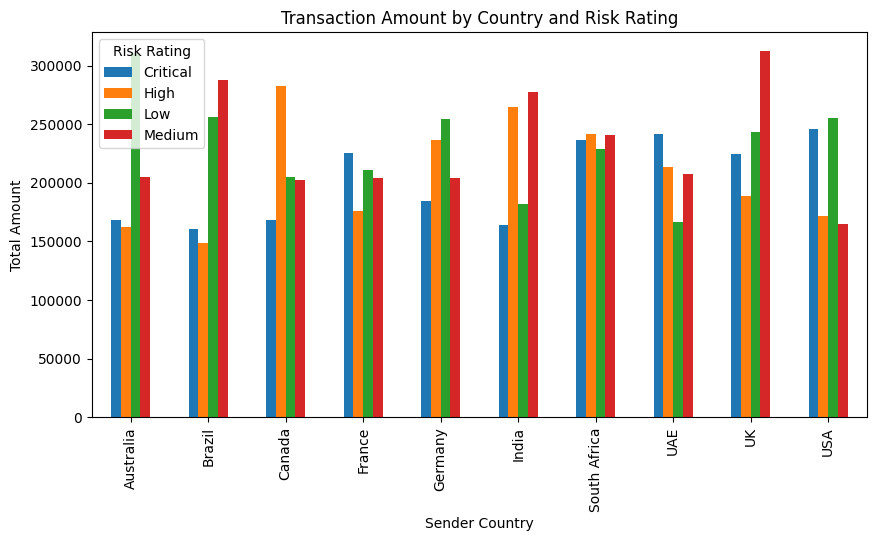

In [ ]:
pivot = pd.pivot_table(
    df,
    values='Amount',
    index='Sender Country',
    columns='Risk Rating',
    aggfunc='sum'
)

pivot.plot(kind='bar', figsize=(10,5))
plt.title('Transaction Amount by Country and Risk Rating')
plt.ylabel('Total Amount')
plt.show()

10. Bubble Chart – Age, Amount and Risk Rating
Features Used
Sender Age
Amount
Risk Rating
Amount (Bubble Size)
What is the chart showing?

A multivariate view combining three or more variables.

What does it tell us?
Bubble size represents transaction value.
Color represents risk level.
Position represents customer age and transaction amount.
Business Insight

This chart helps identify high-risk customers making large transactions. Such customers should be prioritized for monitoring and compliance review.

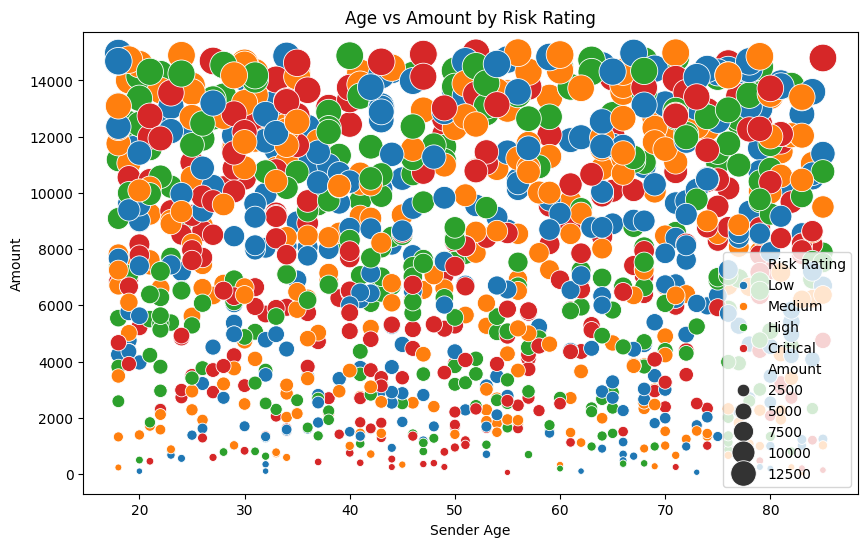

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='Sender Age',
    y='Amount',
    hue='Risk Rating',
    size='Amount',
    sizes=(20,400)
)

plt.title('Age vs Amount by Risk Rating')
plt.show()

## **Steps to Download your cleaned data for dashboard creation using Power BI**


In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/KarthiApi/WesternUnion/main/updated_westernunion_compliance_CleanedDataset.xlsx"

df = pd.read_excel(url)

df.to_csv("cleaned_data.csv", index=False)

df.head()

,Transaction ID,MTCN,SenderName,ReceiverName,PEP,Sender Currency,Receiver Currency2,Sender Country2,Receiver Country2,KYC Status2,Transaction Type2,Amount,Age,Channel,Risk Rating,Timestamp,Customer Address
0,TXN1000001,95822412.0,Patricia Smith,Fatima Rodriguez,No,GBP,BRL,France,Brazil,KYC,Outer-Transaction,3497.59,69.0,Agent Network,Low,2020-07-25 22:28:00,"5241 Cedar Ln, Dubai"
1,TXN1000002,31429110.0,Elena Wilson,Richard Rodriguez,Yes,CAD,EUR,Germany,South Africa,Pending,Outer-Transaction,8048.06,32.0,ATM,Low,2026-01-07 16:31:00,"2808 Main St, Toronto"
2,TXN1000003,20709497.0,Zayn Davis,Zayn Brown,Yes,SGD,ZAR,Germany,Brazil,Pending,External,1080.32,78.0,Web Portal,Medium,2020-06-13 06:29:00,"3373 Pine Rd, London"
3,TXN1000004,17507864.0,Elizabeth Khan,Mary Silva,No,AED,EUR,India,UK,Unverified,External,6888.19,38.0,Branch Counter,Medium,2025-06-21 13:43:00,"8812 Main St, Toronto"
4,TXN1000005,28566572.0,CHARLES THOMAS,Robert Dubois,No,EUR,GBP,Australia,France,Unverified,Internal,3778.70,41.0,Agent Network,Low,2025-09-15 16:31:00,"3651 Oak Ave, Dubai"


## Stage 4 – Documentation, Insights and Presentation

Show a dashboard aligning all the charts in powerbi by connecting python in PowerBI

Summarize findings in plain English (what do the patterns mean)

Highlight 3–5 key insights (trends, anomalies, correlations)

Provide recommendations for business or decision-making

Explain the FINAL STORY WITH THE DASHBOARD/report

Create a PDF pasting your DASHBOARD, explaining all the above mentioned concepts and submit it


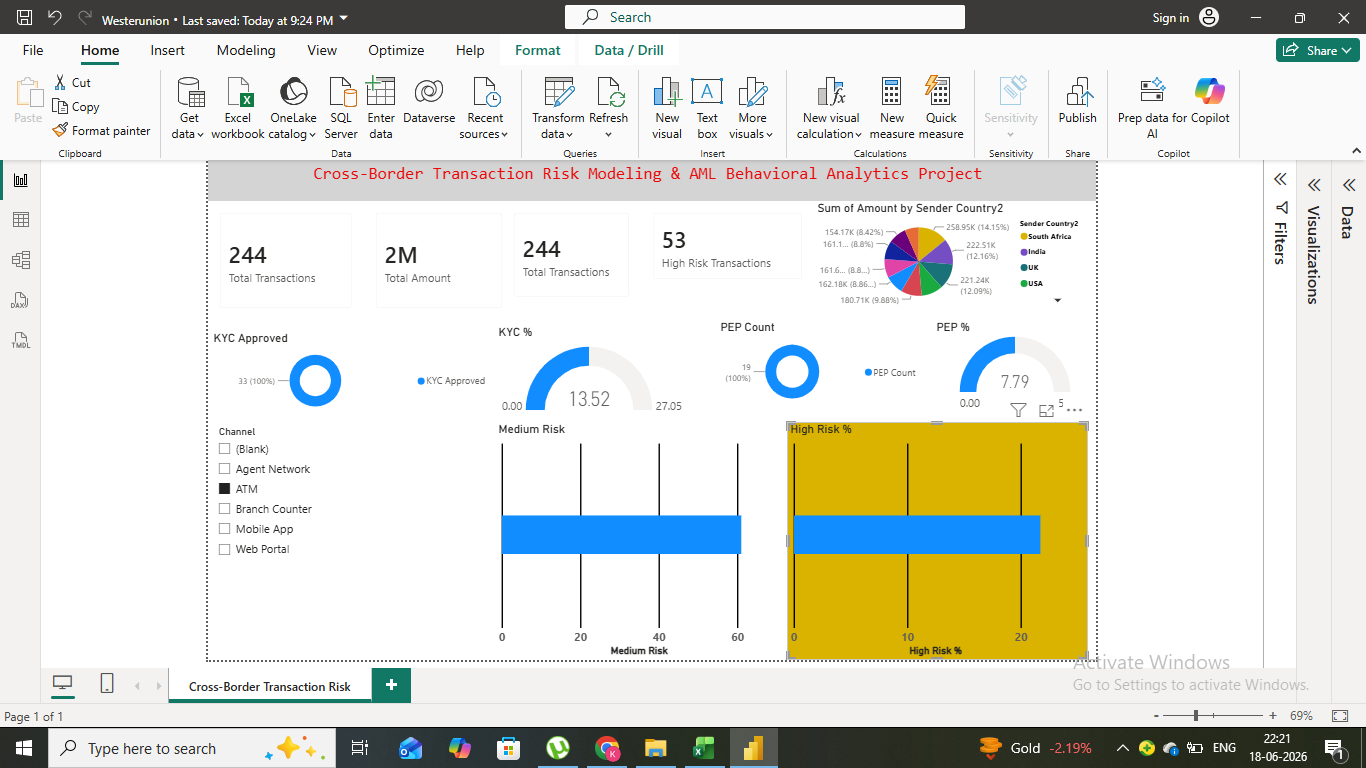

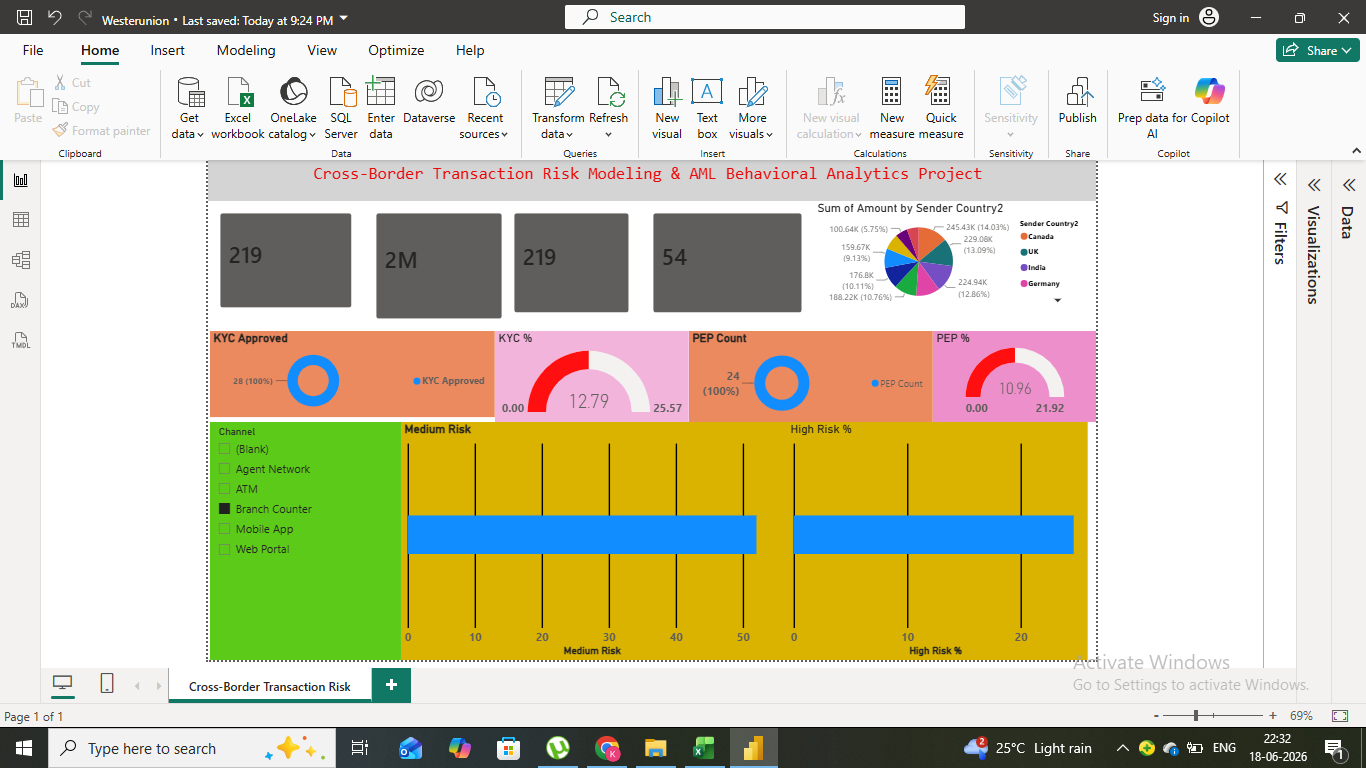

https://github.com/KarthiApi/WesternUnion/upload/main

## **Final Overall Insights:**
* insights from the final dashboard observation on the basics of 4 types of analysis

# Future Enhancement

Use a larger or more recent dataset for deeper insights

Automate parts of the analysis with scripts or dashboards

Add advanced visualizations and interactive dashboards in Power BI or Tableau

Extend the analysis to predictive modeling for forecasting if needed

# Conclusion

From the analysis, we identified meaningful relationships and patterns in the dataset. The visualizations and insights highlight the main factors influencing the outcomes and provide a strong foundation for business decisions.